# 1. Introduction & Setup
# 2. Mathematical Overview (Cost Function & Gradient Descent)
# 3. Data Loading & Exploration
# 4. Fitting the Model
# 5. Visualizing Results & Error Convergence


In [4]:
# Cell 1: Imports (Code)
import sys, os
sys.path.append(os.path.abspath(".."))  # or os.path.abspath(".") if the notebook is in root

import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray

# Import custom regression model and visualization utilities
from src import LinearRegressor, plot_regression

# Configure inline plots for Jupyter
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Mathematical Foundations

Linear Regression models the relationship between a target variable $y$ and feature $x$:
$$\hat{y} = m x + b$$

#### 1. Mean Squared Error (MSE) Cost Function
To measure how well our line fits the data:
$$J(m, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (m x_i + b))^2$$

#### 2. Gradient Descent Updates
We update parameters $m$ and $b$ iteratively using partial derivatives of $J$:
$$m \leftarrow m - \alpha \cdot \left( -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - \hat{y}_i) \right)$$
$$b \leftarrow b - \alpha \cdot \left( -\frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i) \right)$$
*(where $\alpha$ is the learning rate)*

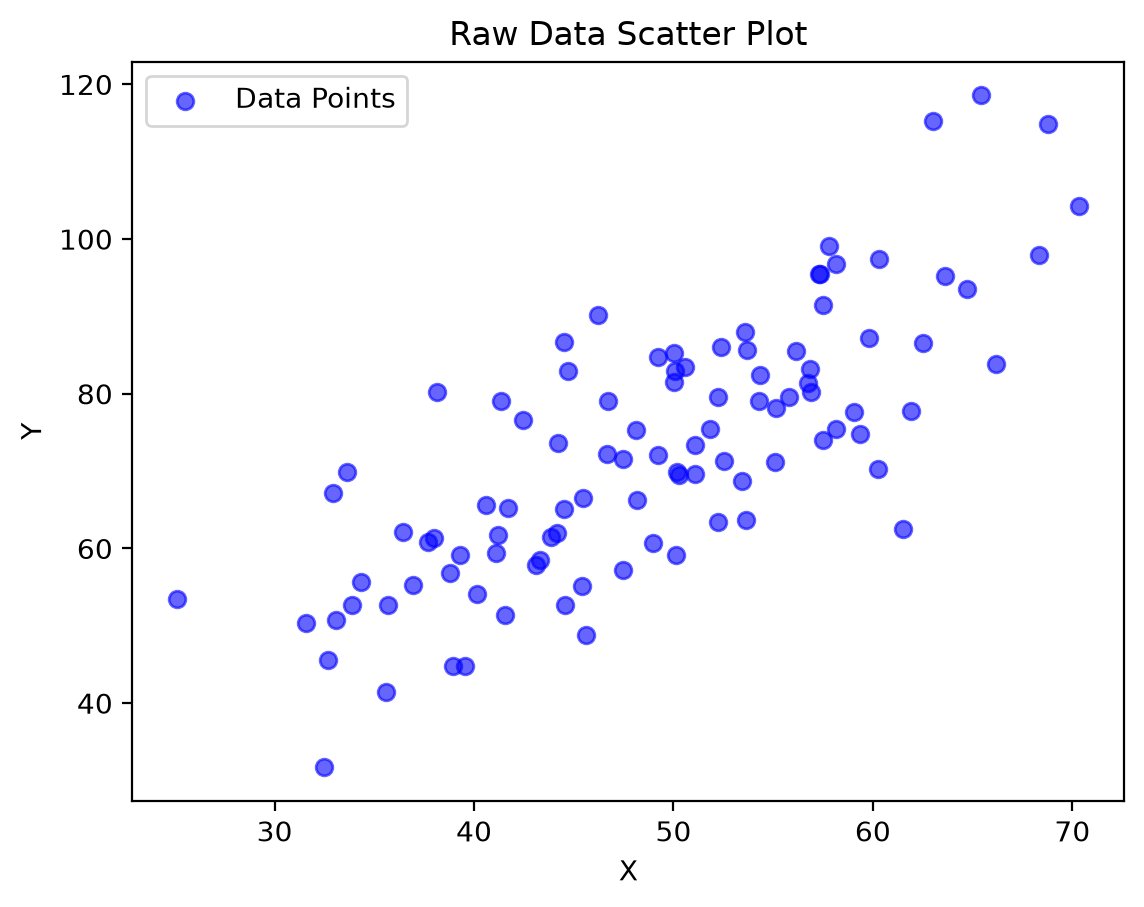

In [8]:
# Cell 2: Load Data (Code)
# Load points (N x 2 array of [x, y] coordinates)
points: NDArray[np.float64] = np.genfromtxt("../data/data.csv", delimiter=",", dtype=np.float64)

# Separate x and y for plotting
x = points[:, 0]
y = points[:, 1]

# Quick scatter plot of raw data
plt.scatter(x, y, color="blue", alpha=0.6, label="Data Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Raw Data Scatter Plot")
plt.legend()
plt.show()

In [10]:
# Cell 3: Training (Code)
# Hyperparameters
learning_rate = 0.0001
num_iterations = 1000

# Initialize model
model = LinearRegressor(learning_rate=learning_rate)

# Initial error before training
initial_error = model.compute_error(points)
print(f"Initial Mean Squared Error: {initial_error:.4f}")

# Fit model
m_final, b_final = model.fit(points, num_iterations=num_iterations)

# Final error
final_error = model.compute_error(points)
print(f"Final Line Equation: y = {m_final:.4f}x + {b_final:.4f}")
print(f"Final Mean Squared Error:   {final_error:.4f}")

Initial Mean Squared Error: 5565.1078
Final Line Equation: y = 1.4777x + 0.0889
Final Mean Squared Error:   112.6148


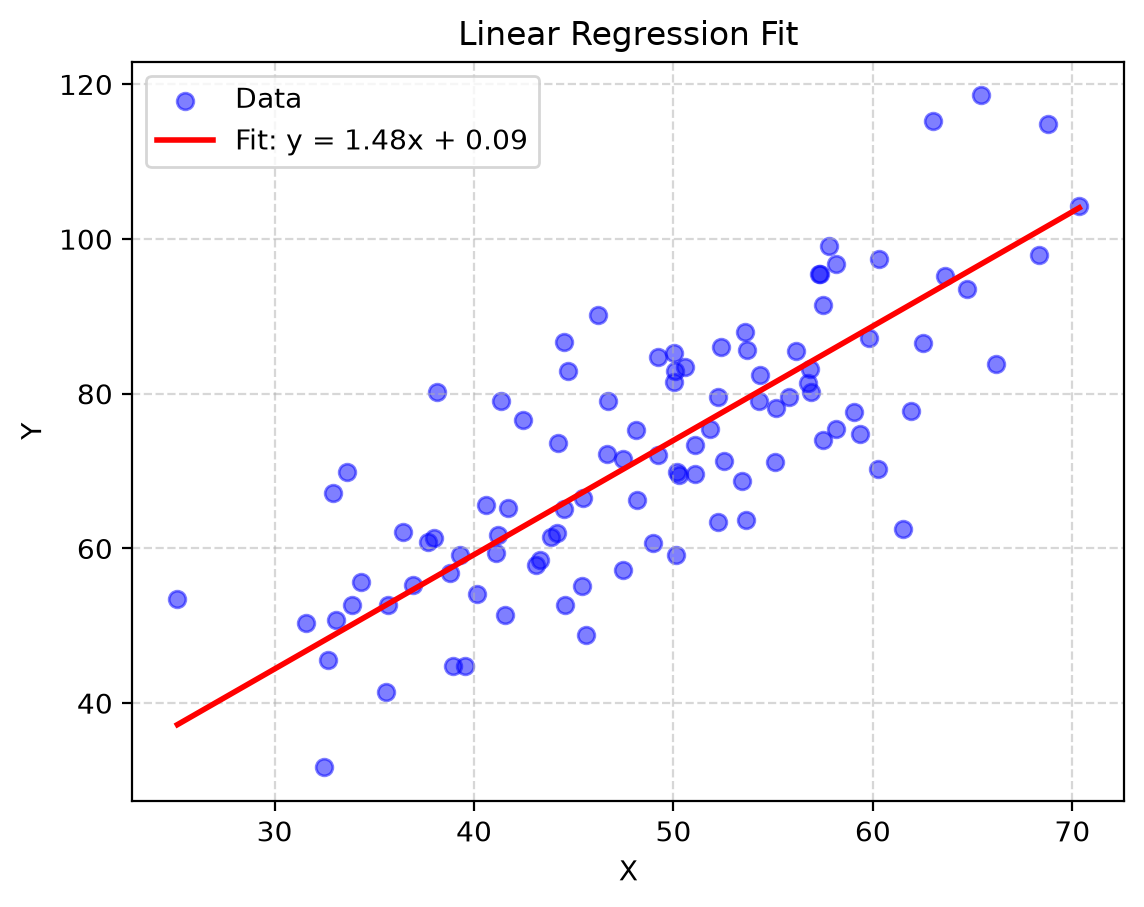

In [11]:
# Cell 4: Plot Regression Line (Code)
# Plot raw points along with the fitted linear regression line
plt.scatter(x, y, color="blue", alpha=0.5, label="Data")

# Plot prediction line
x_vals = np.linspace(min(x), max(x), 100)
y_vals = model.predict(x_vals)

plt.plot(x_vals, y_vals, color="red", linewidth=2, label=f"Fit: y = {m_final:.2f}x + {b_final:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

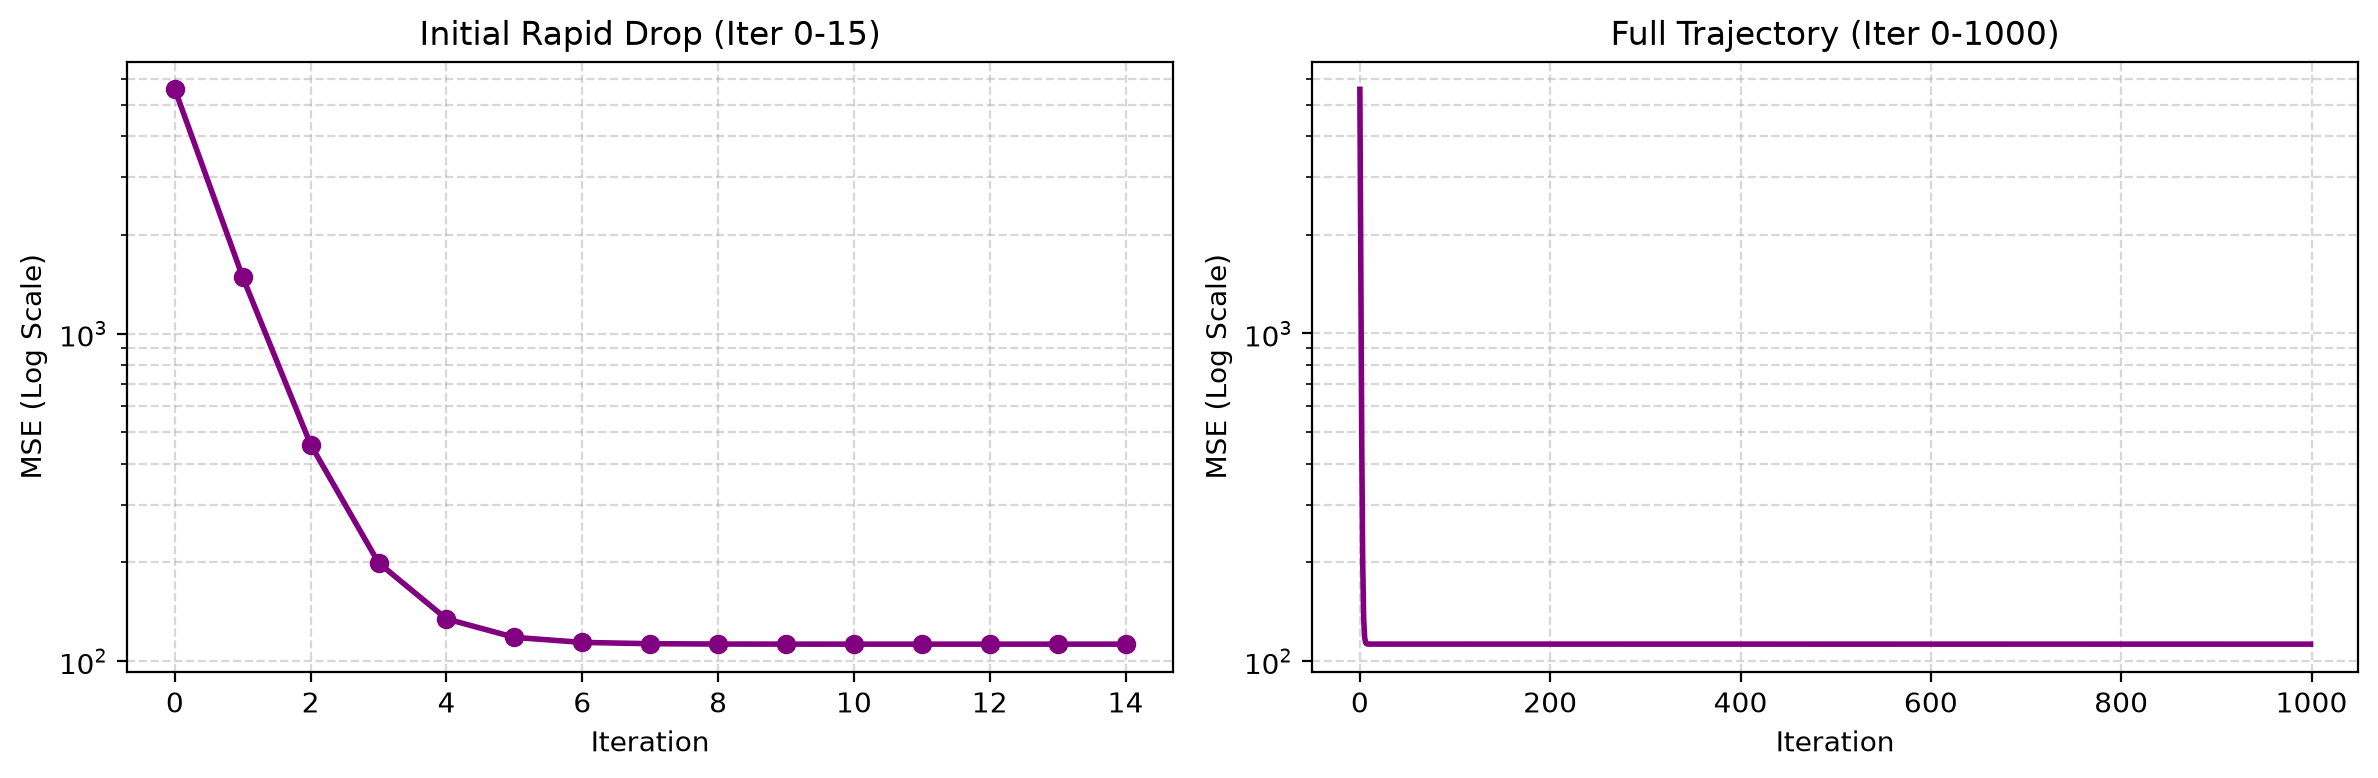

In [15]:
# Train model and track cost history
model = LinearRegressor(learning_rate=0.0001)
model.fit(points, num_iterations=1000)

# Plot MSE Loss over Iterations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left Plot: First 15 Iterations (shows rapid decrease)
ax1.plot(model.cost_history[:15], color="purple", linewidth=2, marker="o")
ax1.set_yscale("log")
ax1.set_title("Initial Rapid Drop (Iter 0-15)")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("MSE (Log Scale)")
ax1.grid(True, which="both", linestyle="--", alpha=0.5)

# Right Plot: Full 1000 Iterations (shows plateau)
ax2.plot(model.cost_history, color="purple", linewidth=2)
ax2.set_yscale("log")
ax2.set_title("Full Trajectory (Iter 0-1000)")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("MSE (Log Scale)")
ax2.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

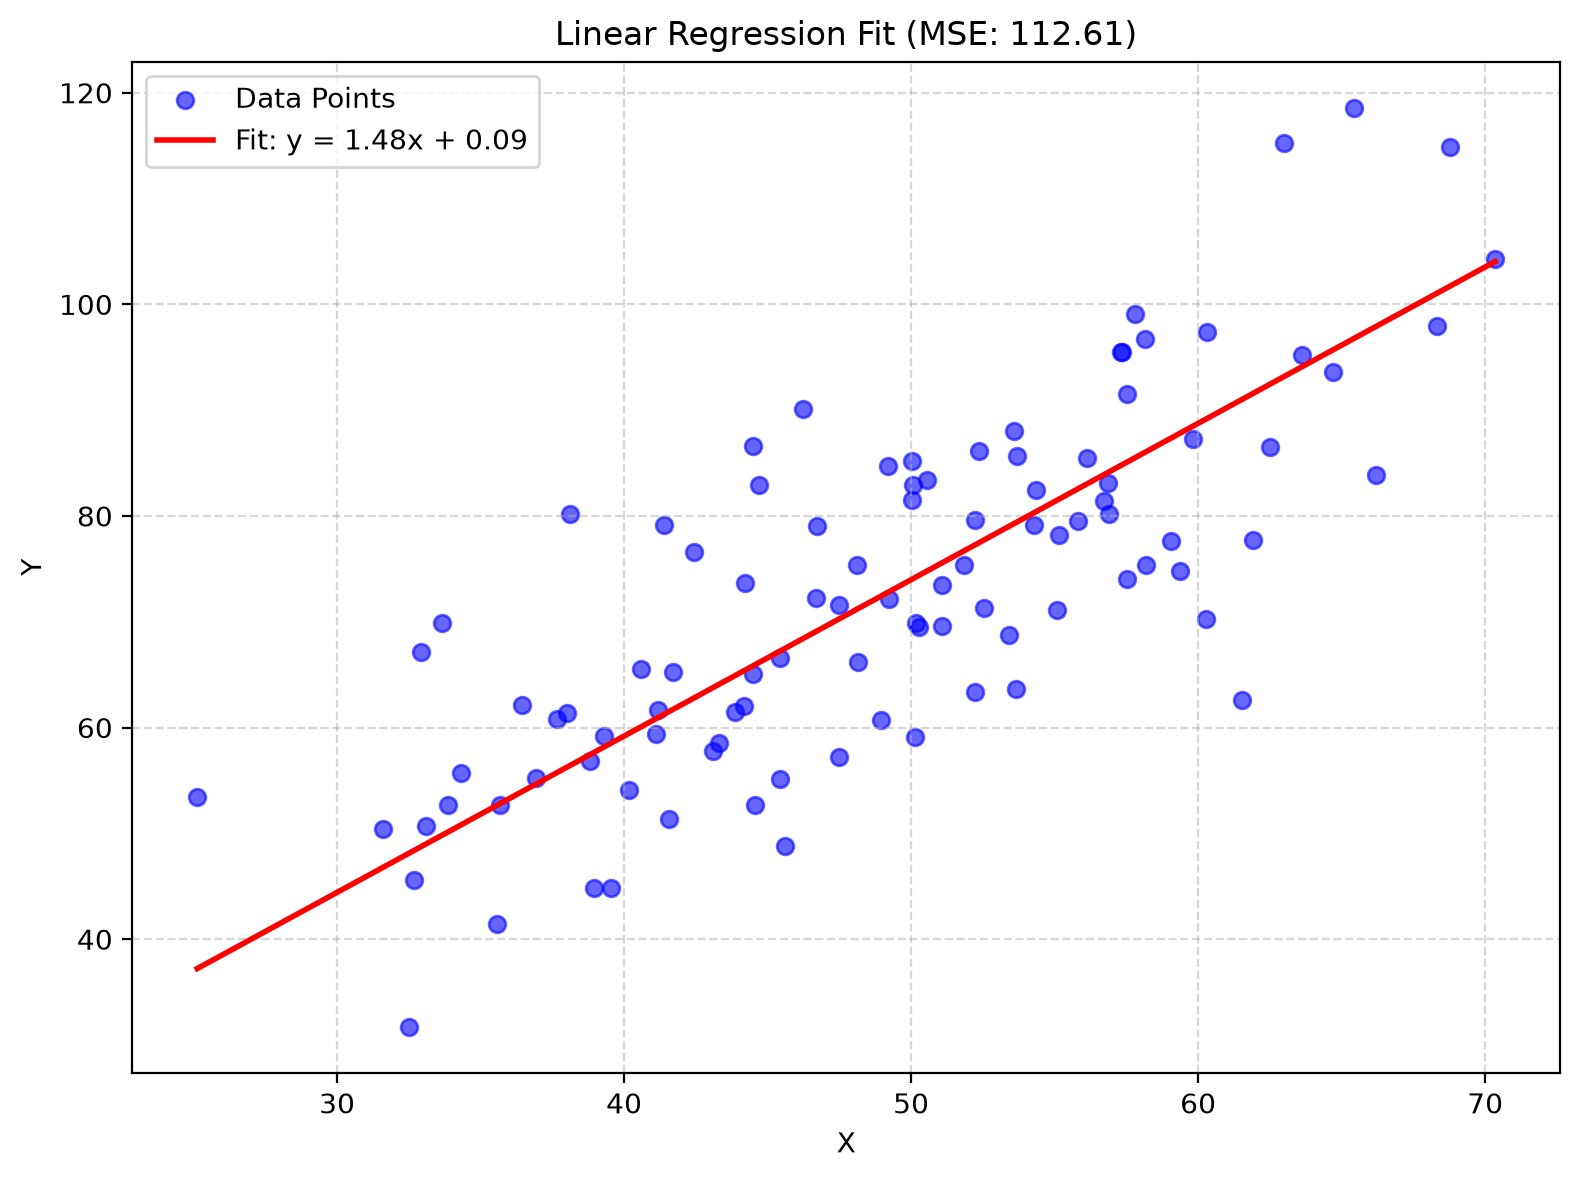

In [20]:
# Compute error first
mse = model.compute_error(points)

# Pass mse to the function
plot_regression(points, model.m, model.b, mse)